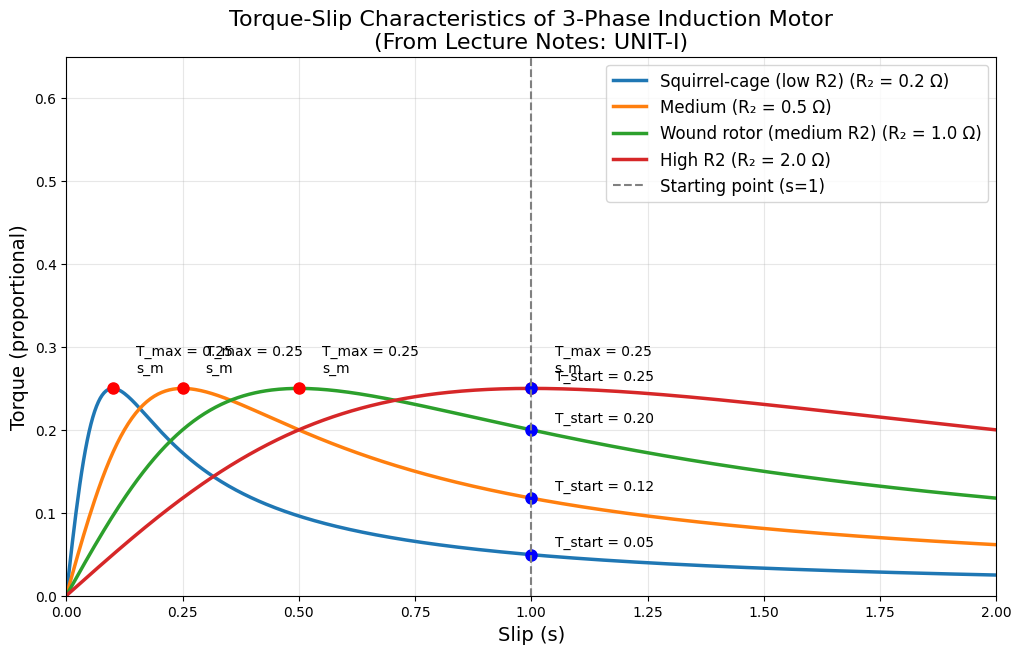

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ====================== PARAMETERS ======================
s = np.linspace(0.001, 2, 500)          # Slip range (0 to 2 covers motoring + plugging)
X2 = 2.0                                # Rotor reactance at standstill (Ω) - fixed
k = 1.0                                 # Proportionality constant (normalize torque)
R2_values = [0.2, 0.5, 1.0, 2.0]        # Different rotor resistances
labels = ['Squirrel-cage (low R2)', 'Medium', 'Wound rotor (medium R2)', 'High R2']

# ====================== PLOT ======================
plt.figure(figsize=(12, 7))

for i, R2 in enumerate(R2_values):
    T = k * (s * R2) / (R2**2 + (s * X2)**2)
    plt.plot(s, T, linewidth=2.5, label=f'{labels[i]} (R₂ = {R2} Ω)')

    # Maximum torque point (analytical: s_m = R2 / X2)
    s_m = R2 / X2
    T_max = k * (s_m * R2) / (R2**2 + (s_m * X2)**2)
    plt.plot(s_m, T_max , 'ro', markersize=8)
    plt.text(s_m + 0.05, T_max + 0.02, f'T_max = {T_max:.2f}\ns_m', fontsize=10)

    # Starting torque (s=1)
    T_start = k * (1 * R2) / (R2**2 + (1 * X2)**2)
    plt.plot(1, T_start, 'bo', markersize=8)
    plt.text(1.05, T_start + 0.01, f'T_start = {T_start:.2f}', fontsize=10)

plt.title('Torque-Slip Characteristics of 3-Phase Induction Motor\n(From Lecture Notes: UNIT-I)', fontsize=16)
plt.xlabel('Slip (s)', fontsize=14)
plt.ylabel('Torque (proportional)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=1, color='gray', linestyle='--', linewidth=1.5, label='Starting point (s=1)')
plt.xlim(0, 2)
plt.ylim(0, 0.65)
plt.legend(fontsize=12)
plt.show()

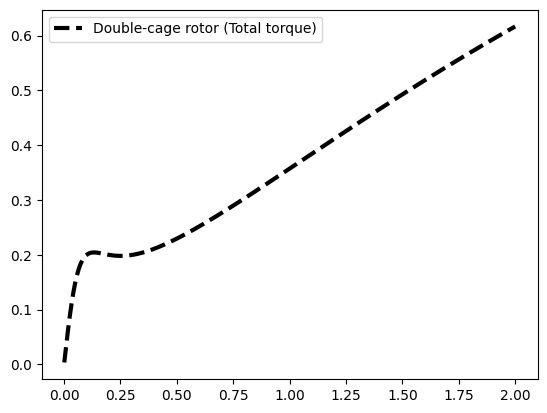

In [4]:
R2o = 3.0      # Outer cage - high resistance
X2o = 0.5      # Outer cage - low reactance
R2i = 0.3      # Inner cage - low resistance
X2i = 3.0      # Inner cage - high reactance

To = k * (s * R2o) / (R2o**2 + (s * X2o)**2)   # Outer cage torque
Ti = k * (s * R2i) / (R2i**2 + (s * X2i)**2)   # Inner cage torque
T_total = To + Ti

plt.plot(s, T_total, 'k--', linewidth=3, label='Double-cage rotor (Total torque)')
plt.legend()